
# Post-Balancing Data Understanding & Professional Preprocessing

**Project:** Quantum-Inspired Federated Framework for Dynamic IoT Networks  
**Use case:** CICIoT2023 intrusion detection after augmentation + training balance  
**Notebook purpose:** turn the balanced dataset into a **clean, validated, documented, training-ready** dataset for centralized, hierarchical, and federated learning.

---

## What this notebook does

### Data understanding
- inventory of available files and dataset versions
- structural profile of the balanced dataset
- class distribution, feature distributions, skewness, and outliers
- missing values, duplicates, constant / near-constant features
- correlations and redundancy analysis
- optional plausibility check of synthetic vs real balanced data
- legal / confidentiality documentation block for the report

### Data preparation
- controlled cleaning pipeline
- feature typing and validation
- optional feature engineering
- robust split strategy (**80/20** or **70/15/15**)
- scaling fitted **only on training data**
- label encoding and artifact export
- publication of a final training-ready dataset bundle

---

## Source paths recovered from the previous balancing notebook

This notebook is built around the paths found in your augmentation notebook:

- input clean dataset: `E:\dataset\processed\merged_full\dataset_34classes_clean.csv`
- balanced dataset: `E:\dataset\processed_merged_full\minority_balancing_v3\dataset_34classes_balanced_v3.csv`
- synthetic-only dataset: `E:\dataset\processed_merged_full\minority_balancing_v3\synthetic_only_v3.csv`
- base balanced without synthetic: `E:\dataset\processed_merged_full\minority_balancing_v3ase_balanced_without_synthetic_v3.csv`
- old training-ready exports: `E:\dataset\processed_merged_full\minority_balancing_v3	raining_ready\`

You can change them in the configuration cell if needed.


In [1]:

from pathlib import Path
import os
import json
import gc
import warnings
import pickle
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, RobustScaler, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import mutual_info_classif

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)
sns.set_theme(style="whitegrid")

SEED = 42
np.random.seed(SEED)


## 1. Configuration

In [2]:
# ============================================================
# CONFIGURATION
# ============================================================

# Original paths recovered from your balancing notebook
ORIGINAL_CLEAN_DATASET = Path(r"E:\dataset\processed\merged_full\dataset_34classes_clean.csv")
BALANCED_DATASET = Path(r"E:\dataset\processed_merged_full\minority_balancing_v3\dataset_34classes_balanced_v3.csv")
SYNTHETIC_ONLY_DATASET = Path(r"E:\dataset\processed_merged_full\minority_balancing_v3\synthetic_only_v3.csv")
BASE_BALANCED_DATASET = Path(r"E:\dataset\processed_merged_full\minority_balancing_v3\base_balanced_without_synthetic_v3.csv")
OLD_TRAINING_READY_DIR = Path(r"E:\dataset\processed_merged_full\minority_balancing_v3\training_ready")

# Portable fallback: if you copy the notebook elsewhere, point to your current root here
# Example:
# PROJECT_ROOT = Path(r"D:\PFE\datasets")
PROJECT_ROOT = None

if PROJECT_ROOT is not None:
    ORIGINAL_CLEAN_DATASET = PROJECT_ROOT / "processed/merged_full/dataset_34classes_clean.csv"
    BALANCED_DATASET = PROJECT_ROOT / "processed_merged_full/minority_balancing_v3/dataset_34classes_balanced_v3.csv"
    SYNTHETIC_ONLY_DATASET = PROJECT_ROOT / "processed_merged_full/minority_balancing_v3/synthetic_only_v3.csv"
    BASE_BALANCED_DATASET = PROJECT_ROOT / "processed_merged_full/minority_balancing_v3/base_balanced_without_synthetic_v3.csv"
    OLD_TRAINING_READY_DIR = PROJECT_ROOT / "processed_merged_full/minority_balancing_v3/training_ready"

# Main input for this notebook
INPUT_DATASET = BALANCED_DATASET
LABEL_COL = "label"
LABEL_ID_COL_CANDIDATE = "label_id_34"

# Output directory for this new professional preprocessing phase
OUTPUT_DIR = INPUT_DATASET.parent / "post_balancing_preprocessing_professional"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ARTIFACTS_DIR = OUTPUT_DIR / "artifacts"
REPORTS_DIR = OUTPUT_DIR / "reports"
FIGURES_DIR = OUTPUT_DIR / "figures"
EXPORTS_DIR = OUTPUT_DIR / "exports"
for p in [ARTIFACTS_DIR, REPORTS_DIR, FIGURES_DIR, EXPORTS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# Loading / profiling controls
NROWS_EDA = 500_000          # smaller sample for fast EDA; set None for full load if machine allows
NROWS_FULL = None            # set None to read full input dataset
DROP_DUPLICATES = True
TRAIN_TEST_SPLIT = 0.20      # requested standard split 80/20
ALSO_CREATE_VAL_SPLIT = True
VAL_RATIO_FROM_TRAIN = 0.125 # 0.125 of train => final 70/10/20 when test=0.20

# Cleaning controls
MISSING_NUMERIC_STRATEGY = "median"   # median is safer than mean on skewed traffic features
REMOVE_CONSTANT_FEATURES = True
REMOVE_NEAR_CONSTANT_FEATURES = True
NEAR_CONSTANT_THRESHOLD = 0.995
REMOVE_HIGH_CORR_FEATURES = False      # start with False; inspect report first, then decide
HIGH_CORR_THRESHOLD = 0.98

# Transformation controls
SCALER_NAME = "robust"  # "robust" or "standard"
APPLY_LOG1P_TO_HEAVY_SKEW = False
SKEW_THRESHOLD_FOR_LOG1P = 5.0

# Export controls
EXPORT_PARQUET = False
EXPORT_CSV = True

print("INPUT_DATASET:", INPUT_DATASET)
print("OUTPUT_DIR   :", OUTPUT_DIR)


INPUT_DATASET: E:\dataset\processed_merged_full\minority_balancing_v3\dataset_34classes_balanced_v3.csv
OUTPUT_DIR   : E:\dataset\processed_merged_full\minority_balancing_v3\post_balancing_preprocessing_professional



## 2. File inventory and legal / confidentiality notes

This block documents the available data assets and adds a short compliance note you can reuse in the report.

### Data understanding checklist
- **Volume:** very large tabular network-flow dataset, millions of rows.
- **Variety:** 32 numeric traffic features + label columns in the balancing notebook.
- **Velocity:** this dataset is stored as static CSV snapshots, but the domain is high-velocity IoT traffic.
- **Quality dimensions:** missing values, duplicates, constant features, skewness, outliers, synthetic plausibility.
- **Legal / confidentiality:** CICIoT2023 is a research dataset, but IDS pipelines should still follow privacy-by-design principles and avoid leaking raw traffic outside the approved environment.

### Practical RGPD / confidentiality note for your report
Even when training is done on benchmark data, the final architecture should preserve:
- minimum necessary data exposure,
- secure storage of intermediate artifacts,
- anonymization / pseudonymization when real traffic is later used,
- access control for exported splits and trained models,
- train-only fitting of preprocessing artifacts to avoid leakage.


In [3]:

file_inventory = pd.DataFrame([
    {"name": "original_clean_dataset", "path": str(ORIGINAL_CLEAN_DATASET), "exists": ORIGINAL_CLEAN_DATASET.exists()},
    {"name": "balanced_dataset", "path": str(BALANCED_DATASET), "exists": BALANCED_DATASET.exists()},
    {"name": "synthetic_only_dataset", "path": str(SYNTHETIC_ONLY_DATASET), "exists": SYNTHETIC_ONLY_DATASET.exists()},
    {"name": "base_balanced_dataset", "path": str(BASE_BALANCED_DATASET), "exists": BASE_BALANCED_DATASET.exists()},
    {"name": "old_training_ready_dir", "path": str(OLD_TRAINING_READY_DIR), "exists": OLD_TRAINING_READY_DIR.exists()},
])
file_inventory


,name,path,exists
0,original_clean_dataset,E:\dataset\processed\merged_full\dataset_34cla...,True
1,balanced_dataset,E:\dataset\processed_merged_full\minority_bala...,True
2,synthetic_only_dataset,E:\dataset\processed_merged_full\minority_bala...,True
3,base_balanced_dataset,E:\dataset\processed_merged_full\minority_bala...,True
4,old_training_ready_dir,E:\dataset\processed_merged_full\minority_bala...,True


## 3. Utility functions

In [4]:

def read_csv_safely(path: Path, nrows: Optional[int] = None) -> pd.DataFrame:
    assert path.exists(), f"File not found: {path}"
    return pd.read_csv(path, nrows=nrows)


def save_json(obj, path: Path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)


def detect_feature_columns(df: pd.DataFrame, label_col: str, label_id_candidate: str) -> Tuple[List[str], List[str], List[str]]:
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    exclude = [c for c in [label_id_candidate] if c in numeric_cols]
    feature_cols = [c for c in numeric_cols if c not in exclude]
    object_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
    return numeric_cols, feature_cols, object_cols


def summarize_dataframe(df: pd.DataFrame, label_col: str) -> pd.DataFrame:
    rows = []
    for col in df.columns:
        s = df[col]
        row = {
            "column": col,
            "dtype": str(s.dtype),
            "missing": int(s.isna().sum()),
            "missing_ratio": float(s.isna().mean()),
            "n_unique": int(s.nunique(dropna=False)),
            "is_numeric": bool(pd.api.types.is_numeric_dtype(s)),
        }
        if pd.api.types.is_numeric_dtype(s):
            row.update({
                "min": float(s.min()) if len(s) else np.nan,
                "q01": float(s.quantile(0.01)) if len(s) else np.nan,
                "median": float(s.median()) if len(s) else np.nan,
                "mean": float(s.mean()) if len(s) else np.nan,
                "q99": float(s.quantile(0.99)) if len(s) else np.nan,
                "max": float(s.max()) if len(s) else np.nan,
                "std": float(s.std(ddof=0)) if len(s) else np.nan,
                "skew": float(s.skew()) if len(s) else np.nan,
                "zero_ratio": float((s == 0).mean()) if len(s) else np.nan,
            })
            vc = s.value_counts(dropna=False, normalize=True)
            row["top_value_ratio"] = float(vc.iloc[0]) if len(vc) else np.nan
        else:
            row.update({
                "min": None, "q01": None, "median": None, "mean": None,
                "q99": None, "max": None, "std": None, "skew": None,
                "zero_ratio": None, "top_value_ratio": float(s.value_counts(dropna=False, normalize=True).iloc[0]) if len(s) else np.nan
            })
        rows.append(row)
    summary = pd.DataFrame(rows)
    summary["is_constant"] = summary["n_unique"] <= 1
    summary["is_near_constant"] = summary["top_value_ratio"].fillna(0) >= NEAR_CONSTANT_THRESHOLD
    return summary


def iqr_outlier_ratio(series: pd.Series) -> float:
    s = series.dropna().astype(float)
    if len(s) == 0:
        return np.nan
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        return 0.0
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    return float(((s < low) | (s > high)).mean())


def build_feature_quality_report(df: pd.DataFrame, feature_cols: List[str]) -> pd.DataFrame:
    rows = []
    for col in feature_cols:
        s = df[col]
        rows.append({
            "feature": col,
            "missing": int(s.isna().sum()),
            "missing_ratio": float(s.isna().mean()),
            "n_unique": int(s.nunique(dropna=False)),
            "zero_ratio": float((s == 0).mean()),
            "std": float(s.std(ddof=0)),
            "skew": float(s.skew()),
            "iqr_outlier_ratio": iqr_outlier_ratio(s),
            "is_constant": bool(s.nunique(dropna=False) <= 1),
            "top_value_ratio": float(s.value_counts(dropna=False, normalize=True).iloc[0]),
            "is_near_constant": bool(s.value_counts(dropna=False, normalize=True).iloc[0] >= NEAR_CONSTANT_THRESHOLD),
        })
    return pd.DataFrame(rows).sort_values(["is_constant", "is_near_constant", "missing_ratio", "iqr_outlier_ratio"], ascending=[False, False, False, False])


def correlation_drop_candidates(df: pd.DataFrame, feature_cols: List[str], threshold: float = 0.98) -> pd.DataFrame:
    corr = df[feature_cols].corr(method="spearman").abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    pairs = []
    for col in upper.columns:
        strong = upper[col][upper[col] > threshold]
        for idx, val in strong.items():
            pairs.append({"feature_a": idx, "feature_b": col, "abs_spearman": float(val)})
    return pd.DataFrame(pairs).sort_values("abs_spearman", ascending=False) if pairs else pd.DataFrame(columns=["feature_a", "feature_b", "abs_spearman"])


def fit_scaler(name: str):
    if name.lower() == "robust":
        return RobustScaler()
    if name.lower() == "standard":
        return StandardScaler()
    raise ValueError(f"Unsupported scaler: {name}")


def optional_log1p_transform(train_df, val_df, test_df, feature_cols, skew_threshold=5.0):
    skew_vals = train_df[feature_cols].skew().abs()
    candidates = skew_vals[skew_vals > skew_threshold].index.tolist()
    safe_candidates = [c for c in candidates if train_df[c].min() >= 0]
    for d in [train_df, val_df, test_df]:
        for c in safe_candidates:
            d[c] = np.log1p(d[c])
    return train_df, val_df, test_df, safe_candidates


## 4. Load dataset for EDA and structural audit

In [ ]:
full_for_eda = pd.read_csv(INPUT_DATASET)
eda_df = full_for_eda.sample(n=min(NROWS_EDA, len(full_for_eda)), random_state=SEED)
print("EDA shape:", eda_df.shape)
eda_df.head()


EDA shape: (500000, 34)


,Header_Length,Protocol Type,Time_To_Live,Rate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,ack_count,HTTP,HTTPS,DNS,Telnet,SMTP,SSH,IRC,TCP,UDP,DHCP,ARP,ICMP,IGMP,Tot sum,Min,Max,AVG,Std,IAT,Number,Variance,label,label_id_34
0,0.20,1.0,65.91,23952.396,0.0,0.00,0.01,0.00,0.01,0.0,1.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.01,0.0,0.0,0.0,0.99,0.0,6000.0,60.0,60.0,60.00,0.00000,0.000042,100.0,0.00000,DDOS-ICMP_FLOOD,6.0
1,0.28,1.0,63.79,42499.790,0.0,0.01,0.00,0.00,0.01,0.0,1.0,0.0,0.01,0.0,0.0,0.0,0.0,0.0,0.01,0.0,0.0,0.0,0.99,0.0,6002.0,60.0,62.0,60.02,0.20000,0.000024,100.0,0.04000,DDOS-ICMP_FLOOD,6.0
2,0.00,1.0,64.00,20538.164,0.0,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,1.00,0.0,6000.0,60.0,60.0,60.00,0.00000,0.000049,100.0,0.00000,DDOS-ICMP_FLOOD,6.0
3,0.64,1.0,67.48,72716.780,0.0,0.00,0.00,0.01,0.02,0.0,2.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0,0.02,0.0,0.0,0.0,0.98,0.0,6108.0,60.0,162.0,61.08,10.21158,0.000014,100.0,104.27637,DDOS-ICMP_FLOOD,6.0
4,0.32,1.0,63.96,47100.550,0.0,0.00,0.00,0.00,0.01,0.0,1.0,0.0,0.01,0.0,0.0,0.0,0.0,0.0,0.01,0.0,0.0,0.0,0.99,0.0,6006.0,60.0,66.0,60.06,0.60000,0.000021,100.0,0.36000,DDOS-ICMP_FLOOD,6.0


In [6]:

numeric_cols, feature_cols, object_cols = detect_feature_columns(eda_df, LABEL_COL, LABEL_ID_COL_CANDIDATE)
print("Numeric columns :", len(numeric_cols))
print("Feature columns :", len(feature_cols))
print("Object columns  :", len(object_cols))
print("Feature columns preview:", feature_cols[:10])


Numeric columns : 33
Feature columns : 32
Object columns  : 1
Feature columns preview: ['Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number']


## 5. Structural profiling

In [7]:

summary_df = summarize_dataframe(eda_df, LABEL_COL)
summary_df.to_csv(REPORTS_DIR / "column_summary.csv", index=False)
summary_df.head(20)


,column,dtype,missing,missing_ratio,n_unique,is_numeric,min,q01,median,mean,q99,max,std,skew,zero_ratio,top_value_ratio,is_constant,is_near_constant
0,Header_Length,float64,0,0.0,908,True,0.000000,0.000000,0.320,3.383295,8.9600,57.76,4.064371,0.784611,0.356330,0.356330,False,False
1,Protocol Type,float64,0,0.0,4,True,0.000000,1.000000,1.000,7.406778,17.0000,17.00,7.831087,0.407280,0.000072,0.597788,False,False
2,Time_To_Live,float64,0,0.0,3654,True,8.860000,62.720000,64.000,64.951694,79.3702,255.00,4.316988,12.390716,0.000000,0.505444,False,False
3,Rate,float64,0,0.0,61767,True,0.006196,1704.445322,20925.484,28241.578647,145534.4800,7340032.00,31766.162853,32.501455,0.000000,0.000210,False,False
4,fin_flag_number,float64,0,0.0,24,True,0.000000,0.000000,0.000,0.000468,0.0100,0.17,0.002748,12.711548,0.960316,0.960316,False,False
5,syn_flag_number,float64,0,0.0,52,True,0.000000,0.000000,0.000,0.001341,0.0200,0.55,0.005169,14.610839,0.892382,0.892382,False,False
6,rst_flag_number,float64,0,0.0,38,True,0.000000,0.000000,0.000,0.000169,0.0100,0.51,0.002921,69.577684,0.989200,0.989200,False,False
7,psh_flag_number,float64,0,0.0,87,True,0.000000,0.000000,0.000,0.001879,0.0200,1.00,0.014047,20.587408,0.899446,0.899446,False,False
8,ack_flag_number,float64,0,0.0,150,True,0.000000,0.000000,0.000,0.006124,0.0600,1.00,0.039841,17.587970,0.760308,0.760308,False,False
9,ece_flag_number,float64,0,0.0,14,True,0.000000,0.000000,0.000,0.000031,0.0000,0.12,0.000875,55.301869,0.997816,0.997816,False,True


In [8]:

class_counts = eda_df[LABEL_COL].value_counts().sort_values(ascending=False)
class_dist_df = class_counts.rename_axis("label").reset_index(name="count")
class_dist_df.to_csv(REPORTS_DIR / "class_distribution_sample.csv", index=False)
class_dist_df.head(20)


,label,count
0,DDOS-ICMP_FLOOD,300000
1,DDOS-UDP_FLOOD,200000


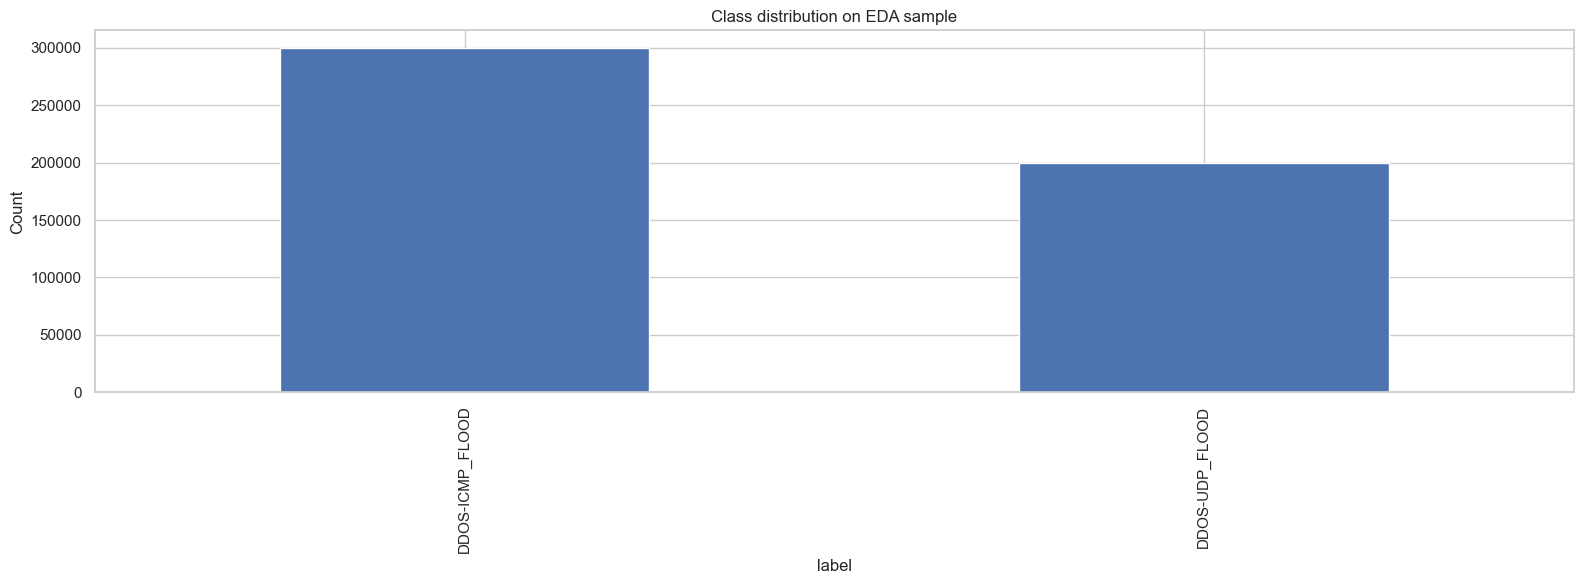

In [9]:

plt.figure(figsize=(16, 6))
class_counts.plot(kind="bar")
plt.title("Class distribution on EDA sample")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "class_distribution_sample.png", dpi=160, bbox_inches="tight")
plt.show()


## 6. Data quality: missing values, duplicates, constants, near-constants, outliers

In [10]:

duplicate_count = int(eda_df.duplicated().sum())
missing_by_col = eda_df.isna().sum().sort_values(ascending=False)

print("Duplicate rows in EDA sample:", duplicate_count)
print("Missing values (top 20):")
display(missing_by_col.head(20))


Duplicate rows in EDA sample: 0
Missing values (top 20):


Header_Length    0
Min              0
UDP              0
DHCP             0
ARP              0
ICMP             0
IGMP             0
Tot sum          0
Max              0
Protocol Type    0
AVG              0
Std              0
IAT              0
Number           0
Variance         0
label            0
TCP              0
IRC              0
SSH              0
SMTP             0
dtype: int64

In [11]:

feature_quality_df = build_feature_quality_report(eda_df, feature_cols)
feature_quality_df.to_csv(REPORTS_DIR / "feature_quality_report_sample.csv", index=False)
feature_quality_df.head(20)


,feature,missing,missing_ratio,n_unique,zero_ratio,std,skew,iqr_outlier_ratio,is_constant,top_value_ratio,is_near_constant
14,Telnet,0,0.0,1,1.000000,0.000000,0.000000,0.000000,True,1.000000,True
15,SMTP,0,0.0,1,1.000000,0.000000,0.000000,0.000000,True,1.000000,True
9,ece_flag_number,0,0.0,14,0.997816,0.000875,55.301869,0.000000,False,0.997816,True
16,SSH,0,0.0,6,0.997282,0.000671,27.627529,0.000000,False,0.997282,True
17,IRC,0,0.0,2,0.999870,0.000114,87.688961,0.000000,False,0.999870,True
23,IGMP,0,0.0,5,0.999132,0.000335,41.517092,0.000000,False,0.999132,True
25,Min,0,0.0,6,0.000000,3.718922,706.561748,0.000000,False,0.999862,True
30,Number,0,0.0,100,0.000000,2.828485,-26.008632,0.000000,False,0.997480,True
2,Time_To_Live,0,0.0,3654,0.000000,4.316988,12.390716,0.244078,False,0.505444,False
31,Variance,0,0.0,25055,0.546448,56318.798684,37.319797,0.195022,False,0.546448,False


In [12]:

constant_candidates = feature_quality_df.loc[feature_quality_df["is_constant"], "feature"].tolist()
near_constant_candidates = feature_quality_df.loc[feature_quality_df["is_near_constant"], "feature"].tolist()

print("Constant features:", constant_candidates)
print("Near-constant features:", near_constant_candidates)


Constant features: ['Telnet', 'SMTP']
Near-constant features: ['Telnet', 'SMTP', 'ece_flag_number', 'SSH', 'IRC', 'IGMP', 'Min', 'Number']


## 7. Distributions and outlier visuals

In [13]:

# Choose a small set of informative columns for quick visual inspection
plot_cols = [c for c in ["Rate", "IAT", "Variance", "Tot sum", "Header_Length", "Time_To_Live", "Std", "AVG"] if c in feature_cols]
plot_cols


['Rate',
 'IAT',
 'Variance',
 'Tot sum',
 'Header_Length',
 'Time_To_Live',
 'Std',
 'AVG']

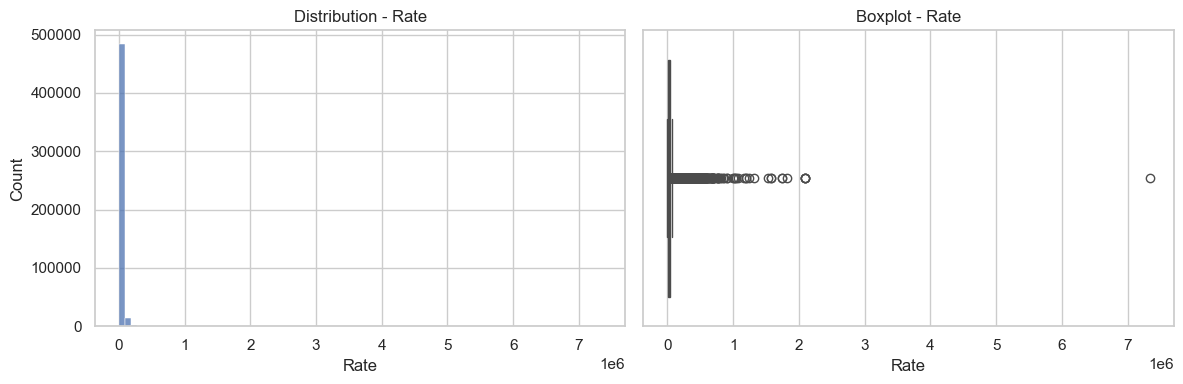

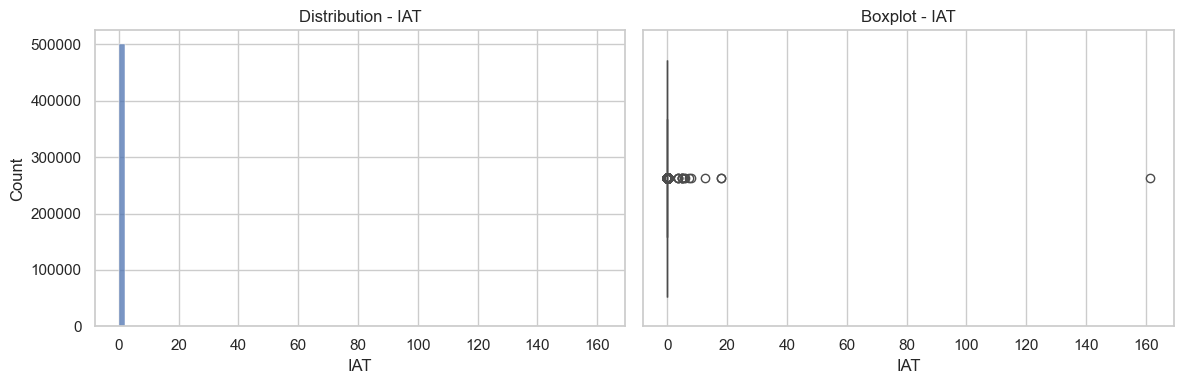

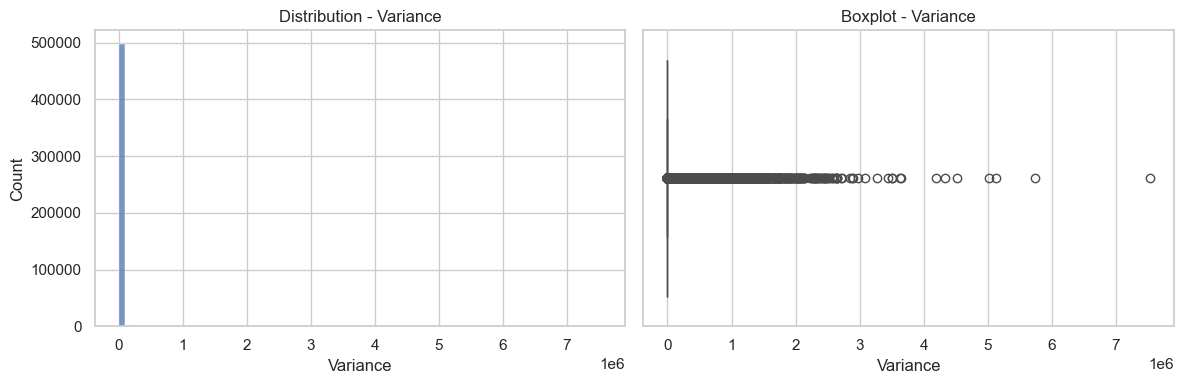

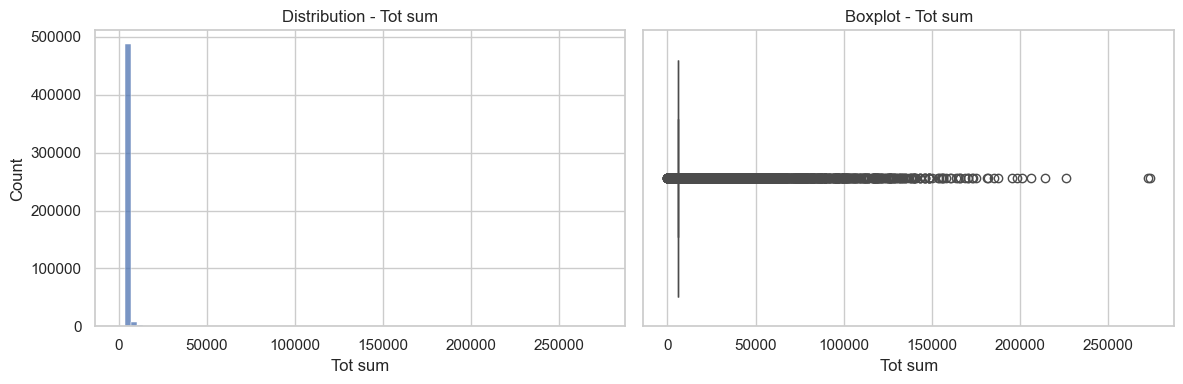

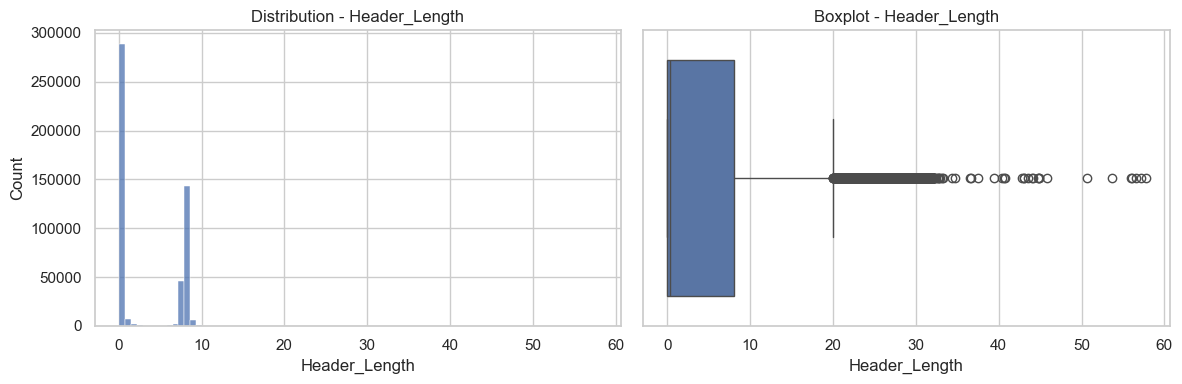

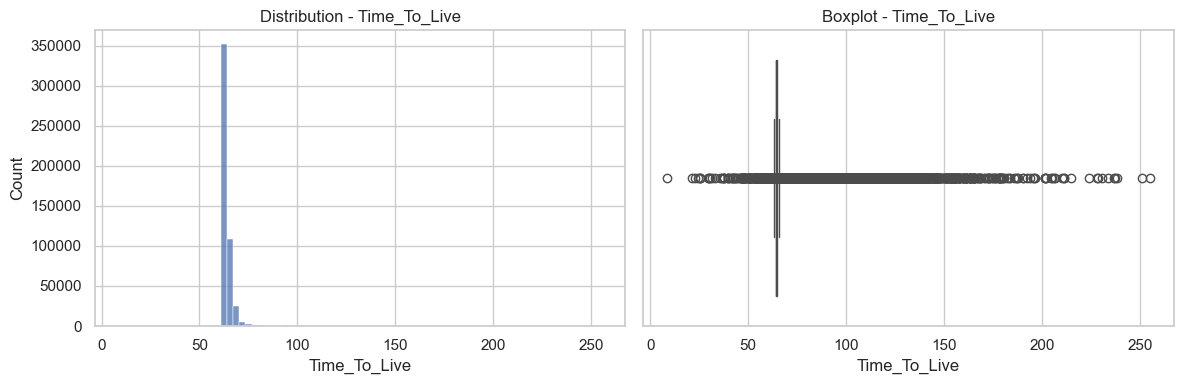

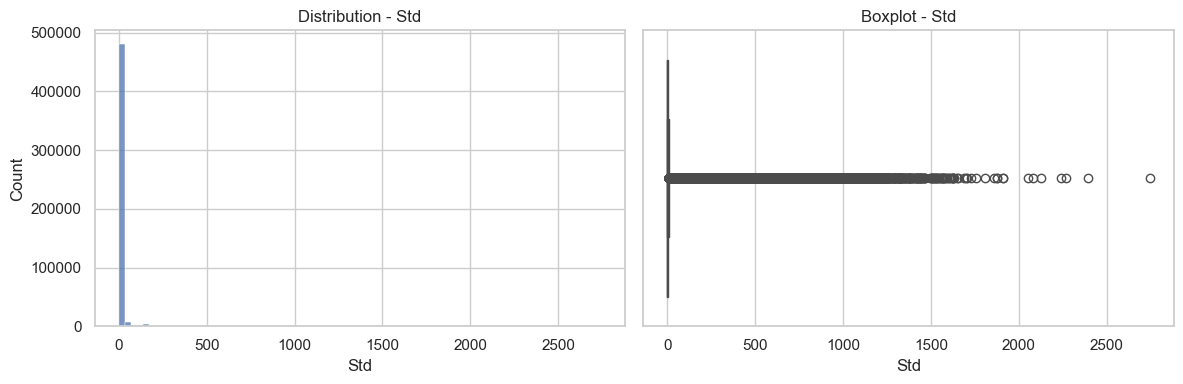

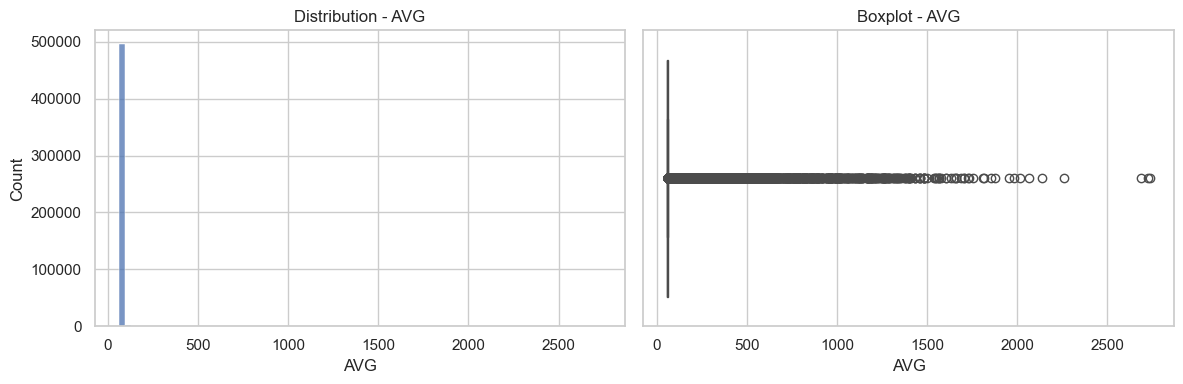

In [14]:

for col in plot_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(eda_df[col], bins=80, ax=axes[0], kde=False)
    axes[0].set_title(f"Distribution - {col}")
    sns.boxplot(x=eda_df[col], ax=axes[1])
    axes[1].set_title(f"Boxplot - {col}")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"dist_box_{col}.png", dpi=160, bbox_inches="tight")
    plt.show()


## 8. Correlation and redundancy analysis

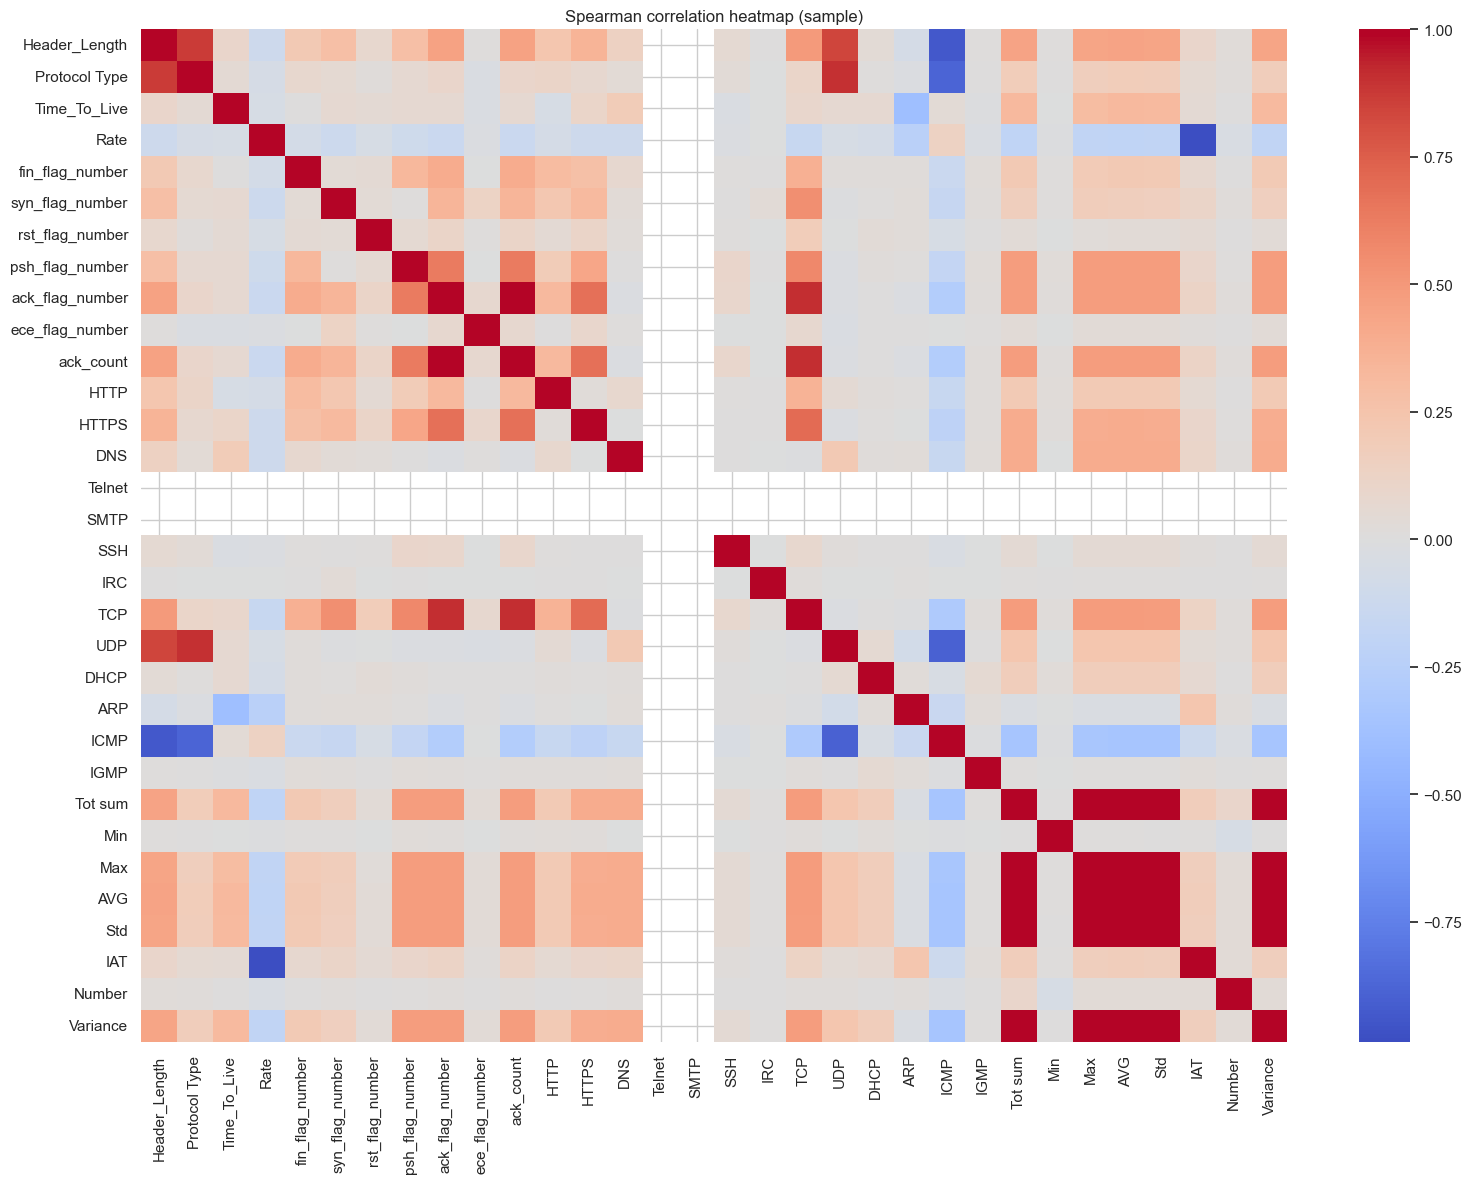

In [15]:

# Use a reduced subset if memory is limited
corr_sample = eda_df[feature_cols].sample(min(len(eda_df), 50_000), random_state=SEED)

corr_matrix = corr_sample.corr(method="spearman")
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Spearman correlation heatmap (sample)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "correlation_heatmap_sample.png", dpi=160, bbox_inches="tight")
plt.show()


In [16]:

high_corr_pairs_df = correlation_drop_candidates(corr_sample, feature_cols, threshold=HIGH_CORR_THRESHOLD)
high_corr_pairs_df.to_csv(REPORTS_DIR / "high_correlation_pairs_sample.csv", index=False)
high_corr_pairs_df.head(30)


,feature_a,feature_b,abs_spearman
11,Std,Variance,1.000000
0,ack_flag_number,ack_count,0.999981
6,AVG,Std,0.997993
10,AVG,Variance,0.997993
2,Tot sum,AVG,0.997447
5,Max,Std,0.997418
9,Max,Variance,0.997418
4,Tot sum,Std,0.995711
8,Tot sum,Variance,0.995711
3,Max,AVG,0.992022


## 9. Optional synthetic plausibility check

In [17]:

plausibility_summary_df = None
if SYNTHETIC_ONLY_DATASET.exists() and BASE_BALANCED_DATASET.exists():
    base_df = read_csv_safely(BASE_BALANCED_DATASET, nrows=min(NROWS_EDA, 300_000) if NROWS_EDA else 300_000)
    synth_df = read_csv_safely(SYNTHETIC_ONLY_DATASET, nrows=min(NROWS_EDA, 300_000) if NROWS_EDA else 300_000)

    rows = []
    common_labels = sorted(set(base_df[LABEL_COL].unique()).intersection(set(synth_df[LABEL_COL].unique())))
    for label in common_labels:
        real_part = base_df[base_df[LABEL_COL] == label]
        synth_part = synth_df[synth_df[LABEL_COL] == label]
        if len(real_part) == 0 or len(synth_part) == 0:
            continue
        for col in feature_cols:
            rows.append({
                "label": label,
                "feature": col,
                "real_mean": float(real_part[col].mean()),
                "synth_mean": float(synth_part[col].mean()),
                "abs_mean_diff": float(abs(real_part[col].mean() - synth_part[col].mean())),
                "real_std": float(real_part[col].std(ddof=0)),
                "synth_std": float(synth_part[col].std(ddof=0)),
            })

    plausibility_df = pd.DataFrame(rows)
    plausibility_df.to_csv(REPORTS_DIR / "synthetic_plausibility_report_sample.csv", index=False)
    plausibility_summary_df = (
        plausibility_df.groupby("label")[["abs_mean_diff", "real_std", "synth_std"]]
        .mean()
        .reset_index()
        .sort_values("abs_mean_diff")
    )
    plausibility_summary_df.to_csv(REPORTS_DIR / "synthetic_plausibility_summary_sample.csv", index=False)

plausibility_summary_df.head(20) if plausibility_summary_df is not None else "Synthetic/base-balanced files not found."


KeyError: 'label'


## 10. Load full dataset for the actual preprocessing pipeline

Use the full balanced dataset if your machine allows it. If RAM is limited, reduce the file before running or convert it to parquet beforehand.


In [ ]:

full_df = read_csv_safely(INPUT_DATASET, nrows=NROWS_FULL)
print("Full shape before cleaning:", full_df.shape)


In [ ]:

if DROP_DUPLICATES:
    dup_full = int(full_df.duplicated().sum())
    print("Duplicate rows in full dataset:", dup_full)
    if dup_full > 0:
        full_df = full_df.drop_duplicates().reset_index(drop=True)
        print("Shape after duplicate removal:", full_df.shape)

numeric_cols_full, feature_cols_full, object_cols_full = detect_feature_columns(full_df, LABEL_COL, LABEL_ID_COL_CANDIDATE)
print("Final feature count before selection:", len(feature_cols_full))


## 11. Cleaning decisions

In [ ]:

full_feature_quality_df = build_feature_quality_report(full_df, feature_cols_full)
full_feature_quality_df.to_csv(REPORTS_DIR / "feature_quality_report_full.csv", index=False)

constant_features_full = full_feature_quality_df.loc[full_feature_quality_df["is_constant"], "feature"].tolist()
near_constant_features_full = full_feature_quality_df.loc[full_feature_quality_df["is_near_constant"], "feature"].tolist()

features_to_drop = []
if REMOVE_CONSTANT_FEATURES:
    features_to_drop.extend(constant_features_full)
if REMOVE_NEAR_CONSTANT_FEATURES:
    features_to_drop.extend(near_constant_features_full)

features_to_drop = sorted(set(features_to_drop))
selected_feature_cols = [c for c in feature_cols_full if c not in features_to_drop]

print("Features to drop after constant / near-constant audit:", features_to_drop)
print("Selected features count:", len(selected_feature_cols))


In [ ]:

if REMOVE_HIGH_CORR_FEATURES:
    corr_pairs_full = correlation_drop_candidates(full_df.sample(min(len(full_df), 100_000), random_state=SEED), selected_feature_cols, threshold=HIGH_CORR_THRESHOLD)
    corr_pairs_full.to_csv(REPORTS_DIR / "high_correlation_pairs_full.csv", index=False)

    to_drop_corr = set(corr_pairs_full["feature_b"].tolist())
    selected_feature_cols = [c for c in selected_feature_cols if c not in to_drop_corr]
    print("Dropped due to high correlation:", sorted(to_drop_corr))
    print("Selected features count after correlation filtering:", len(selected_feature_cols))


## 12. Split strategy (80/20 + optional validation)

In [ ]:

model_df = full_df[selected_feature_cols + [LABEL_COL]].copy()

train_df, test_df = train_test_split(
    model_df,
    test_size=TRAIN_TEST_SPLIT,
    stratify=model_df[LABEL_COL],
    random_state=SEED,
)

if ALSO_CREATE_VAL_SPLIT:
    train_df, val_df = train_test_split(
        train_df,
        test_size=VAL_RATIO_FROM_TRAIN,
        stratify=train_df[LABEL_COL],
        random_state=SEED,
    )
else:
    val_df = None

print("Train shape:", train_df.shape)
print("Val shape  :", None if val_df is None else val_df.shape)
print("Test shape :", test_df.shape)


## 13. Imputation, optional transformation, scaling, and label encoding

In [18]:
plausibility_summary_df = None

if SYNTHETIC_ONLY_DATASET.exists() and BASE_BALANCED_DATASET.exists():
    base_df = read_csv_safely(BASE_BALANCED_DATASET, nrows=min(NROWS_EDA, 300_000) if NROWS_EDA else 300_000)
    synth_df = read_csv_safely(SYNTHETIC_ONLY_DATASET, nrows=min(NROWS_EDA, 300_000) if NROWS_EDA else 300_000)

    print("Base labels found :", sorted(base_df[LABEL_COL].unique()))
    print("Synth labels found:", sorted(synth_df[LABEL_COL].unique()))

    rows = []
    common_labels = sorted(set(base_df[LABEL_COL].unique()).intersection(set(synth_df[LABEL_COL].unique())))
    print("Common labels:", common_labels)

    for label in common_labels:
        real_part = base_df[base_df[LABEL_COL] == label]
        synth_part = synth_df[synth_df[LABEL_COL] == label]

        if len(real_part) == 0 or len(synth_part) == 0:
            continue

        for col in feature_cols:
            rows.append({
                "label": label,
                "feature": col,
                "real_mean": float(real_part[col].mean()),
                "synth_mean": float(synth_part[col].mean()),
                "abs_mean_diff": float(abs(real_part[col].mean() - synth_part[col].mean())),
                "real_std": float(real_part[col].std(ddof=0)),
                "synth_std": float(synth_part[col].std(ddof=0)),
            })

    if len(rows) > 0:
        plausibility_df = pd.DataFrame(rows)
        plausibility_df.to_csv(REPORTS_DIR / "synthetic_plausibility_report_sample.csv", index=False)

        plausibility_summary_df = (
            plausibility_df.groupby("label")[["abs_mean_diff", "real_std", "synth_std"]]
            .mean()
            .reset_index()
            .sort_values("abs_mean_diff")
        )
        plausibility_summary_df.to_csv(REPORTS_DIR / "synthetic_plausibility_summary_sample.csv", index=False)
    else:
        print("No common labels found in the sampled portions of base_df and synth_df.")
        plausibility_summary_df = pd.DataFrame(columns=["label", "abs_mean_diff", "real_std", "synth_std"])

plausibility_summary_df.head(20) if plausibility_summary_df is not None else "Synthetic/base-balanced files not found."

Base labels found : ['DDOS-ICMP_FLOOD']
Synth labels found: ['DDOS-ACK_FRAGMENTATION', 'DDOS-UDP_FRAGMENTATION', 'DNS_SPOOFING', 'MITM-ARPSPOOFING', 'RECON-HOSTDISCOVERY']
Common labels: []
No common labels found in the sampled portions of base_df and synth_df.


,label,abs_mean_diff,real_std,synth_std


## 14. Final export datasets

In [ ]:

train_ready = pd.concat([X_train_scaled, y_train.reset_index(drop=True), y_train_enc.reset_index(drop=True)], axis=1)
test_ready = pd.concat([X_test_scaled, y_test.reset_index(drop=True), y_test_enc.reset_index(drop=True)], axis=1)
val_ready = pd.concat([X_val_scaled, y_val.reset_index(drop=True), y_val_enc.reset_index(drop=True)], axis=1) if X_val_scaled is not None else None

if EXPORT_CSV:
    train_ready.to_csv(EXPORTS_DIR / "train_ready.csv", index=False)
    test_ready.to_csv(EXPORTS_DIR / "test_ready.csv", index=False)
    if val_ready is not None:
        val_ready.to_csv(EXPORTS_DIR / "val_ready.csv", index=False)

if EXPORT_PARQUET:
    train_ready.to_parquet(EXPORTS_DIR / "train_ready.parquet", index=False)
    test_ready.to_parquet(EXPORTS_DIR / "test_ready.parquet", index=False)
    if val_ready is not None:
        val_ready.to_parquet(EXPORTS_DIR / "val_ready.parquet", index=False)

with open(ARTIFACTS_DIR / "imputer.pkl", "wb") as f:
    pickle.dump(imputer, f)
with open(ARTIFACTS_DIR / "scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
with open(ARTIFACTS_DIR / "label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

pd.DataFrame({
    "feature": selected_feature_cols,
    "order": range(len(selected_feature_cols))
}).to_csv(ARTIFACTS_DIR / "selected_features.csv", index=False)

pd.DataFrame({
    "label": label_encoder.classes_,
    "label_id": range(len(label_encoder.classes_))
}).to_csv(ARTIFACTS_DIR / "label_mapping.csv", index=False)

pipeline_summary = {
    "input_dataset": str(INPUT_DATASET),
    "n_rows_after_cleaning": int(len(model_df)),
    "train_shape": list(train_ready.shape),
    "val_shape": None if val_ready is None else list(val_ready.shape),
    "test_shape": list(test_ready.shape),
    "selected_feature_count": int(len(selected_feature_cols)),
    "dropped_features": features_to_drop,
    "scaler_name": SCALER_NAME,
    "missing_numeric_strategy": MISSING_NUMERIC_STRATEGY,
    "apply_log1p": APPLY_LOG1P_TO_HEAVY_SKEW,
    "log1p_features": log1p_applied_features,
    "train_test_split": TRAIN_TEST_SPLIT,
    "has_validation_split": ALSO_CREATE_VAL_SPLIT,
    "seed": SEED,
}
save_json(pipeline_summary, REPORTS_DIR / "preprocessing_pipeline_summary.json")

print("Exports saved to:", EXPORTS_DIR)
print("Artifacts saved to:", ARTIFACTS_DIR)


## 15. Publish a compact preprocessing report

In [ ]:

report_lines = []
report_lines.append("# Post-Balancing Preprocessing Report")
report_lines.append("")
report_lines.append(f"- Input dataset: `{INPUT_DATASET}`")
report_lines.append(f"- Rows after cleaning: `{len(model_df):,}`")
report_lines.append(f"- Selected features: `{len(selected_feature_cols)}`")
report_lines.append(f"- Dropped features: `{features_to_drop}`")
report_lines.append(f"- Scaler: `{SCALER_NAME}`")
report_lines.append(f"- Missing strategy: `{MISSING_NUMERIC_STRATEGY}`")
report_lines.append(f"- Log1p applied: `{APPLY_LOG1P_TO_HEAVY_SKEW}`")
report_lines.append(f"- Train shape: `{train_ready.shape}`")
report_lines.append(f"- Val shape: `{None if val_ready is None else val_ready.shape}`")
report_lines.append(f"- Test shape: `{test_ready.shape}`")
report_lines.append("")
report_lines.append("## Main findings")
report_lines.append("")
report_lines.append("- The dataset is already numeric except for the class label.")
report_lines.append("- Post-balancing preprocessing must still check duplicates, feature stability, skewness, outliers, and redundancy.")
report_lines.append("- Scaling is fitted on training data only to prevent leakage.")
report_lines.append("- The final exported artifacts are ready for centralized, hierarchical, and federated pipelines.")

report_path = REPORTS_DIR / "PREPROCESSING_REPORT.md"
report_path.write_text("
".join(report_lines), encoding="utf-8")
print("Saved report:", report_path)



## 16. Recommended next steps

1. Run this notebook once on the full balanced dataset.  
2. Inspect `feature_quality_report_full.csv` and `high_correlation_pairs_full.csv`.  
3. If needed, rerun with `REMOVE_HIGH_CORR_FEATURES = True` after reviewing the candidates.  
4. Train the flat baseline and the hierarchical pipeline on the new `train_ready / val_ready / test_ready` exports.  
5. Reuse the same `selected_features.csv`, `imputer.pkl`, `scaler.pkl`, and `label_encoder.pkl` in your FL experiments.
